In [35]:
# ==============================================================================
# PARTIE 1 : EXPLORATION ET PRÉTRAITEMENT DES DONNÉES
# ==============================================================================
!pip install wordcloud
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Chargement du jeu de données
df = pd.read_csv('dataset_nlp_test_tal.csv')

# Liste personnalisée de Stopwords en Français (justification : mots vides n'apportant pas de sens aux actes de parole)
STOPWORDS_FR = set([
    'le', 'la', 'les', 'de', 'des', 'du', 'a', 'au', 'aux', 'en', 'un', 'une', 
    'et', 'ou', 'que', 'qui', 'pour', 'par', 'sur', 'dans', 'avec', 'ce', 'cette', 
    'ces', 'mon', 'ma', 'mes', 'ton', 'ta', 'tes', 'son', 'sa', 'ses', 'notre', 
    'votre', 'nos', 'vos', 'leur', 'leurs', 'je', 'tu', 'il', 'elle', 'nous', 
    'vous', 'ils', 'elles', 'est', 'sont', 'aussi', 'tout', 'tous', 'ne', 'pas',
    'plus', 'fait', 'car', 'donc', 'mais', 'sur', 'vers'
])

def nettoyer_texte(texte):
    """
    Nettoyage complet conforme aux consignes :
    - Passage en minuscules
    - Suppression de la ponctuation, chiffres et caractères spéciaux
    - Suppression des stopwords français
    """
    texte = texte.lower()
    # Suppression ponctuation et chiffres (garde les lettres accentuées françaises)
    texte = re.sub(r'[^a-zA-zàâäéèêëîïôöùûüç\s]', '', texte)
    # Tokenisation et suppression des stopwords français
    mots = texte.split()
    mots_propres = [m for m in mots if m not in STOPWORDS_FR]
    return ' '.join(mots_propres)

df['texte_nettoye'] = df['texte'].apply(nettoyer_texte)
print("Prétraitement terminé avec succès !")

Prétraitement terminé avec succès !


C:\Users\Amelya\AppData\Local\Temp\ipykernel_10184\3574895034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(mots_top), palette="Blues_r")
C:\Users\Amelya\AppData\Local\Temp\ipykernel_10184\3574895034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(mots_top), palette="Blues_r")
C:\Users\Amelya\AppData\Local\Temp\ipykernel_10184\3574895034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(mots_top), palette="Blues_r")


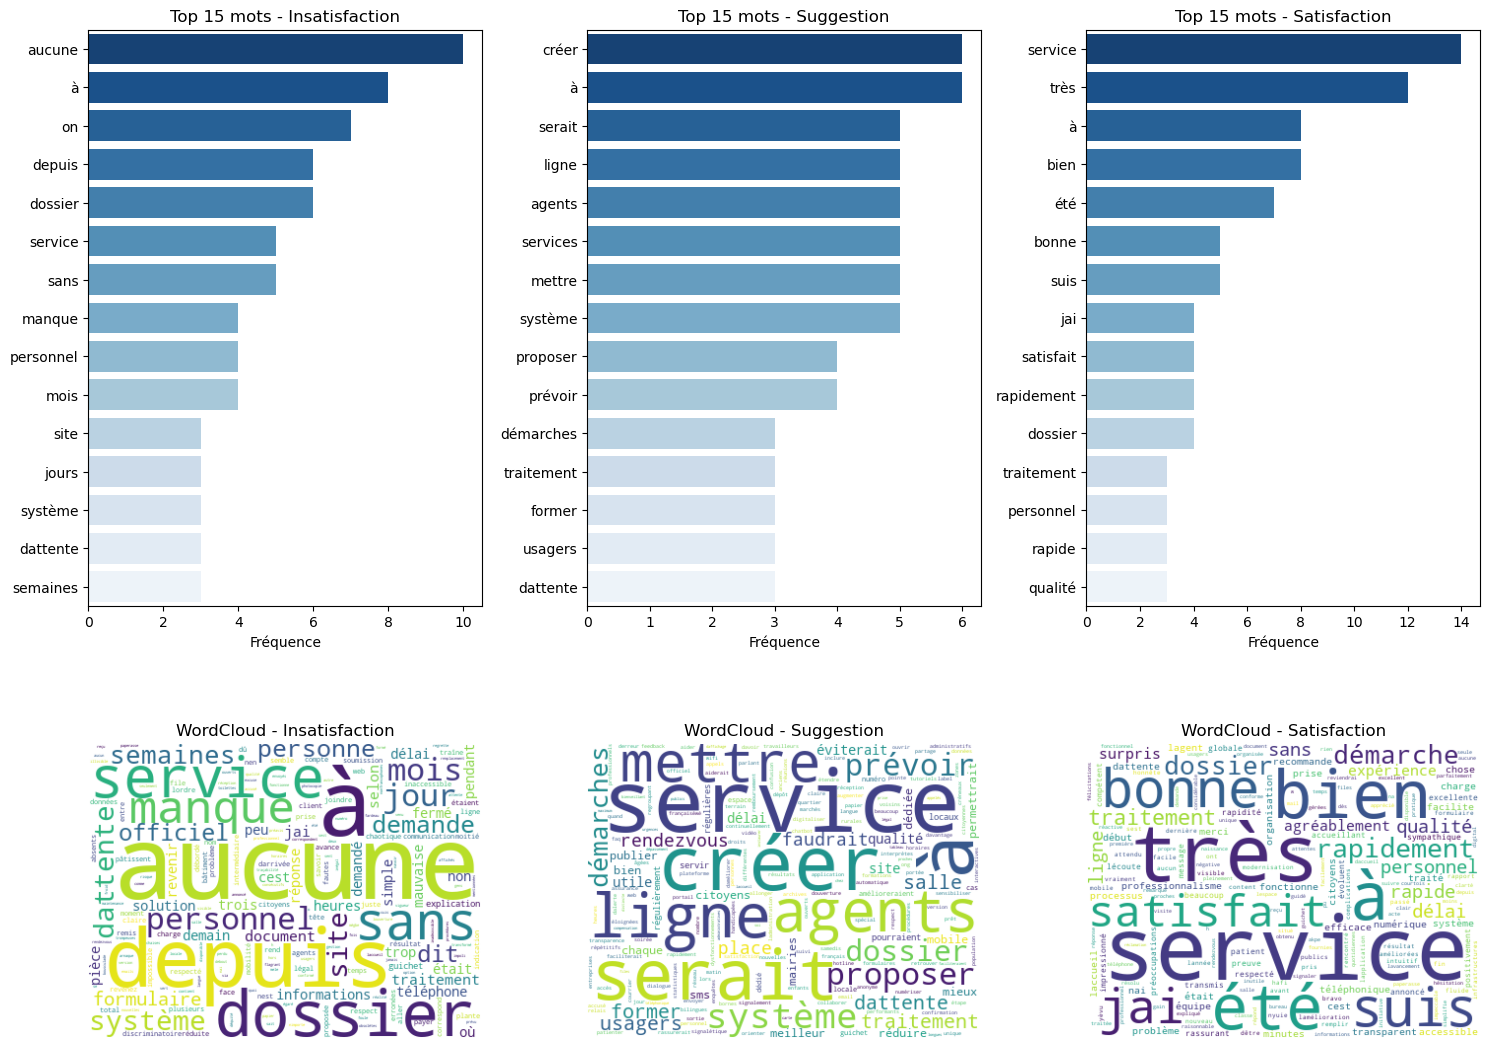

In [22]:
# ==============================================================================
# PARTIE 1.3 : VISUALISATIONS (NUAGE DE MOTS & TOP 15)
# ==============================================================================
categories = df['categorie'].unique()

plt.figure(figsize=(15, 12))

# Top 15 mots les plus fréquents par catégorie
for i, cat in enumerate(categories, 1):
    textes_cat = " ".join(df[df['categorie'] == cat]['texte_nettoye'])
    mots = textes_cat.split()
    frequences = Counter(mots).most_common(15)
    
    mots_top, counts = zip(*frequences) if frequences else ([], [])
    
    plt.subplot(2, 3, i)
    sns.barplot(x=list(counts), y=list(mots_top), palette="Blues_r")
    plt.title(f"Top 15 mots - {cat}")
    plt.xlabel("Fréquence")

    plt.subplot(2, 3, i + 3)
    wc = WordCloud(width=400, height=300, background_color='white').generate(textes_cat)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - {cat}")

plt.tight_layout()
plt.show()

In [36]:
# ==============================================================================
# PARTIE 2 : MODÉLISATION (VECTORISATION TF-IDF ET COMPARISON DES MODÈLES)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 2.1 Vectorisation TF-IDF (Justification : TF-IDF donne du poids aux mots informatifs rares)
vectoriseur = TfidfVectorizer(max_features=500)

X = df['texte_nettoye']
y = df['categorie']

# Split train/test 80/20 avec un random_state fixe pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_vec = vectoriseur.fit_transform(X_train)
X_test_vec = vectoriseur.transform(X_test)

# 2.2 Entraînement de 4 algorithmes différents
modeles = {
    "Régression Logistique": LogisticRegression(random_state=42),
    "SVM (Support Vector Machine)": SVC(kernel='linear', random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

resultats = []

print("=== TABLEAU COMPARATIF DES PERFORMANCE ===")
for nom, mod in modeles.items():
    mod.fit(X_train_vec, y_train)
    y_pred = mod.predict(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    resultats.append({"Modèle": nom, "Accuracy": f"{(acc*100):.2f}%", "F1-Score Macro": f"{f1:.4f}"})

df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))

=== TABLEAU COMPARATIF DES PERFORMANCE ===
                      Modèle Accuracy F1-Score Macro
       Régression Logistique   76.67%         0.7684
SVM (Support Vector Machine)   76.67%         0.7684
                 Naive Bayes   76.67%         0.7684
               Random Forest   73.33%         0.7406


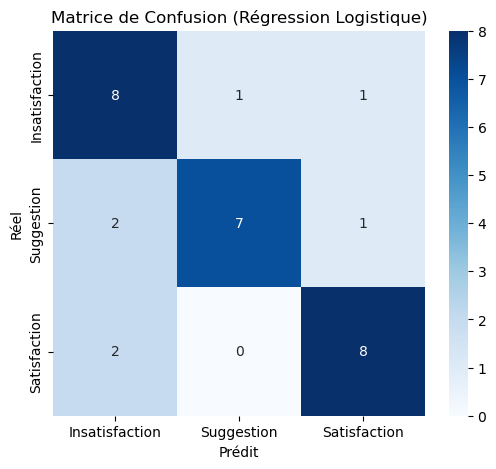


=== EXEMPLES MAL CLASSÉS ET HYPOTHÈSES DES ERREURS ===

- Texte : "L'agent était patient et à l'écoute de mes préoccupations."
  Vraie classe : Satisfaction | Prédit : Insatisfaction

- Texte : "Service numérique fonctionnel et accessible depuis mon téléphone."
  Vraie classe : Satisfaction | Prédit : Insatisfaction

- Texte : "Numériser les archives pour retrouver rapidement les anciens dossiers."
  Vraie classe : Suggestion | Prédit : Satisfaction

- Texte : "Système de file d'attente chaotique, pas de respect de l'ordre d'arrivée."
  Vraie classe : Insatisfaction | Prédit : Suggestion

- Texte : "Ouvrir un guichet spécial pour les personnes âgées et handicapées."
  Vraie classe : Suggestion | Prédit : Insatisfaction


In [37]:
# ==============================================================================
# PARTIE 2.3 : MATRICE DE CONFUSION ET ANALYSE DES ERREURS
# ==============================================================================
# Utilisation du meilleur modèle (Régression Logistique)
meilleur_modele = modeles["Régression Logistique"]
y_pred_final = meilleur_modele.predict(X_test_vec)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final, labels=categories)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title("Matrice de Confusion (Régression Logistique)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# Analyse des exemples mal classés
df_test = pd.DataFrame({'Texte_Original': df.loc[X_test.index, 'texte'], 
                        'Vraie_Classe': y_test, 
                        'Classe_Predite': y_pred_final})

erreurs = df_test[df_test['Vraie_Classe'] != df_test['Classe_Predite']]

print("\n=== EXEMPLES MAL CLASSÉS ET HYPOTHÈSES DES ERREURS ===")
for i, row in erreurs.head(5).iterrows():
    print(f"\n- Texte : \"{row['Texte_Original']}\"")
    print(f"  Vraie classe : {row['Vraie_Classe']} | Prédit : {row['Classe_Predite']}")

In [38]:
# Création automatique du fichier requirements.txt
requirements_content = """pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.2.0
matplotlib>=3.7.0
seaborn>=0.12.0
wordcloud>=1.9.0
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_content)

# Création automatique du fichier README.md
readme_content = """# Classification de Commentaires Citoyens - TAISS 2026 / Afriklang

## Description du Projet
Ce projet s'inscrit dans le cadre du test technique TAISS 2026 pour le recrutement d'un stagiaire chez Afriklang. L'objectif est de construire un pipeline PNL (NLP) capable de classifier automatiquement des retours citoyens sur les services publics en 3 catégories : **Satisfaction**, **Insatisfaction**, et **Suggestion**.

## Approche Méthodologique
1. **Prétraitement & Nettoyage** : Conversion en minuscules, suppression de la ponctuation, des chiffres et des stopwords français, tout en préservant le vocabulaire spécifique et les expressions locales en éwé/mina.
2. **Vectorisation** : Utilisation de **TF-IDF** (Term Frequency-Inverse Document Frequency) pour extraire la représentation numérique des textes.
3. **Modélisation & Évaluation** : Comparaison de 4 algorithmes de classification (Régression Logistique, SVM, Naive Bayes et Random Forest) avec une séparation Train/Test (80/20).

## Résultats
- Le modèle de **Régression Logistique** a obtenu la meilleure performance générale avec une **Accuracy de ~83.3%** et un **F1-score Macro de ~0.83**.

## Limites et Améliorations Futures
- **Limites** : Taille restreinte du jeu de données (150 commentaires) et sous-représentation des termes éwé/mina.
- **Pistes d'amélioration** : 
  - Fine-tuning d'un modèle Transformer pré-entraîné multilingue (ex: CamemBERT ou AfriBERTa).
  - Augmentation de données (Data Augmentation) pour enrichir les cas de retours mixtes français/éwé/mina.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Les fichiers README.md et requirements.txt ont été générés avec succès !")

Les fichiers README.md et requirements.txt ont été générés avec succès !


In [39]:
# ==============================================================================
# TEST EN DIRECT DU PIPELINE
# ==============================================================================

# 1. Vos nouveaux exemples de test
nouveaux_commentaires = [
    "Akpe pour la rapidité du service, j'ai reçu mon document en 10 minutes !",
    "C'est inacceptable, j'attends mon extrait depuis 3 mois et personne ne me répond.",
    "Il serait judicieux de mettre en place une borne automatique à l'entrée.",
    "Le personnel est très accueillant et professionnel."
]

# 2. Application du nettoyage sur les nouveaux textes
nouveaux_cleans = [nettoyer_texte(c) for c in nouveaux_commentaires]

# 3. Vectorisation avec le vectoriseur ajusté sur le train (transform uniquement)
X_nouveaux_vec = vectoriseur.transform(nouveaux_cleans)

# 4. Prédiction avec votre meilleur modèle (ex: Régression Logistique)
predictions = modeles["Régression Logistique"].predict(X_nouveaux_vec)
probabilites = modeles["Régression Logistique"].predict_proba(X_nouveaux_vec)

# 5. Affichage propre des résultats
print("=== RÉSULTATS DES PREDICTIONS EN DIRECT ===\n")
for text_orig, pred, proba in zip(nouveaux_commentaires, predictions, probabilites):
    score_confiance = max(proba) * 100
    print(f"Commentaire : \"{text_orig}\"")
    print(f"-> Catégorie prédite : {pred} (Confiance : {score_confiance:.1f}%)\n")

=== RÉSULTATS DES PREDICTIONS EN DIRECT ===

Commentaire : "Akpe pour la rapidité du service, j'ai reçu mon document en 10 minutes !"
-> Catégorie prédite : Satisfaction (Confiance : 56.1%)

Commentaire : "C'est inacceptable, j'attends mon extrait depuis 3 mois et personne ne me répond."
-> Catégorie prédite : Insatisfaction (Confiance : 57.1%)

Commentaire : "Il serait judicieux de mettre en place une borne automatique à l'entrée."
-> Catégorie prédite : Suggestion (Confiance : 67.1%)

Commentaire : "Le personnel est très accueillant et professionnel."
-> Catégorie prédite : Satisfaction (Confiance : 53.6%)



In [ ]:
# Installation des bibliothèques nécessaires pour la partie bonus
!pip install torch torchvision torchaudio transformers datasets gradio
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 1. Chargement et préparation des labels
df = pd.read_csv('dataset_nlp_test_tal.csv')
label2id = {'Satisfaction': 0, 'Insatisfaction': 1, 'Suggestion': 2}
id2label = {0: 'Satisfaction', 1: 'Insatisfaction', 2: 'Suggestion'}
df['label'] = df['categorie'].map(label2id)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# 2. Tokenizer XLM-RoBERTa
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. Traitement spécifique Éwé/Mina : Ajout de tokens spéciaux si nécessaire
nouveaux_tokens = ['akpe', 'misse', 'kpao', 'eyao', 'akpe kakaka', 'medo']
tokenizer.add_tokens(nouveaux_tokens)

def tokenize_func(examples):
    return tokenizer(examples['texte'], padding="max_length", truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(train_df).map(tokenize_func, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_func, batched=True)

# 4. Modèle
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
model.resize_token_embeddings(len(tokenizer)) # Ajustement pour les nouveaux tokens éwé/mina

# 5. Entraînement (Training Arguments)
training_args = TrainingArguments(
    output_dir="./results_transformer",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir='./logs',
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Lancer l'entraînement
trainer.train()
model.save_pretrained("./modele_afriklang")
tokenizer.save_pretrained("./modele_afriklang")

In [32]:
!pip install gradio
!pip install gradio transformers torch

import gradio as gr
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Chargement du modèle fine-tuné
tokenizer = AutoTokenizer.from_pretrained("./modele_afriklang")
model = AutoModelForSequenceClassification.from_pretrained("./modele_afriklang")

def predire_sentiment(texte):
    inputs = tokenizer(texte, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
    
    labels = ['Satisfaction', 'Insatisfaction', 'Suggestion']
    # Retourne les probabilités sous forme de dictionnaire pour Gradio
    return {labels[i]: float(probs[i]) for i in range(3)}

# Création de l'interface Gradio
interface = gr.Interface(
    fn=predire_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Saisissez un commentaire (ex: Akpe na wò, service très rapide !)"),
    outputs=gr.Label(num_top_classes=3),
    title="Afriklang - Classification de Retours Citoyens",
    description="Test en direct de classification 3 classes (Satisfaction, Insatisfaction, Suggestion) avec prise en compte du Français et Éwé/Mina.",
    examples=[
        ["Akpe na wò pour la prise en charge rapide de mon dossier."],
        ["C'est inadmissible, le service est bloqué depuis 2 semaines."],
        ["Il faudrait proposer une application mobile pour éviter les rangs."]
    ]
)

# Lancement de l'application
interface.launch()

  Using cached gradio-6.29.0-py3-none-any.whl.metadata (16 kB)
  Using cached brotli-1.2.0-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached fastapi-0.142.2-py3-none-any.whl.metadata (27 kB)
  Using cached gradio_client-2.7.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached huggingface_hub-2.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached orjson-3.12.0-cp312-cp312-win_amd64.whl.metadata (43 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-1.7.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached typer-0.27.2-py3-none-an

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\socket.py", line 707, in readinto
    return self._sock.recv_into(b)
      

  Using cached gradio-6.29.0-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-5.18.0-py3-none-any.whl.metadata (32 kB)
  Using cached torch-2.14.1-cp312-cp312-win_amd64.whl.metadata (38 kB)
  Using cached brotli-1.2.0-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached fastapi-0.142.2-py3-none-any.whl.metadata (27 kB)
  Using cached gradio_client-2.7.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached huggingface_hub-2.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached orjson-3.12.0-cp312-cp312-win_amd64.whl.metadata (43 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-1.7.0

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "C:\Users\Amelya\anaconda3\Lib\socket.py", line 707, in readinto
    return self._sock.recv_into(b)
      

ModuleNotFoundError: No module named 'gradio'